# run_spheric

This file represents a notebook/script used to run and test spheric.

Note that this notebook has been paired with a python script file in the `percent` format using `jupytext`.  Use that file for comparing revisions. See [Collaborating on notebooks with git](https://github.com/mwouts/jupytext#collaborating-on-notebooks-with-git) for more details.

# SpherIC documentation

Here is the CLI help menu (Note the nonstandard `-help` and `-version` options are not mentioned):

```
-halo               : generate a dark matter halo
-Nhalo <value>      : number of halo particles
-Mhalo <value>      : total mass of the halo (default Mhalo = 1)
-a <value>          : alpha parameter in the halo density profile
-b <value>          : beta parameter in the halo density profile
-c <value>          : gamma parameter in the halo density profile
-rs <value>         : scale radius (default rs = 1)
-rcutoff <value>    : cutoff radius for cutoff halo models (i.e. beta >= 3)
-king               : generate a stellar component with a King profile
-hernquist          : generate a stellar component with a Hernquist profile
-plummer            : generate a stellar component with a Plummer profile
-Nstar <value>      : number of star particles
-Mstar <value>      : total stellar mass 
-rc <value>         : king core radius
-rt <value>         : king tidal radius
-rhern <value>      : scale radius for Hernquist profile
-rp <value>         : scale radius for Plummer profile
-MBH <value>        : mass of black hole (default MBH = 0)
-name <value>       : name of the output file
-dx/dy/dz <value>   : position offset for the initial conditions (default All = 0)
-dvx/dvy/dvz <value>: velocity offset for the initial conditions (default All = 0)
-ogr                : set this flag for outputting grid in r in an ASCII file
-ogdf               : set this flag for outputting grid for distribution function in an ASCII file
-ogb                : set this flag for generating a GADGET2 initial conditions binary file
-ogh                : set this flag for generating a GIZMO initial conditions HDF5 file
-otb                : set this flag for generating a TIPSY initial conditions binary file
-oift               : set this flag to write positions for IFRIT binary file 
-opfs               : set this flag to write a table of density profiles in an ASCII file
-nostarpot          : set this flag for excluding the stellar potential 
-randomseed <value> : set this flag for setting a value for a random seed (default: random value)
-dorvirexact        : set this flag for calculating rvir exactly via N^2 sum - Warning: time consuming for large N!
```

From running and code analysis, I think the `rs` parameter actually defaults to `-1` aka no default.

Note: SpherIC assumes units of $10^{10}$ M$_{\odot}$, kpc, and km/s. 

# Imports

In [1]:
import numpy as np
import subprocess
from pathlib import Path

# Definitions

## Options class

In [2]:
import inspect
import numbers

class SphericOptions:
    halo = True        # generate a dark matter halo
    Nhalo = 1e5        # number of halo particles
    Mhalo = 1          # total mass of the halo (default Mhalo = 1)
    alpha = 1          # alpha parameter in the halo density profile
    beta = 3           # beta parameter in the halo density profile
    gamma = 1          # gamma parameter in the halo density profile
    rs = 1             # scale radius (default rs = 1)
    rcutoff = 100      # cutoff radius for cutoff halo models (i.e. beta >= 3)
    king = False       # generate a stellar component with a King profile
    hernquist = False  # generate a stellar component with a Hernquist profile
    plummer = False    # generate a stellar component with a Plummer profile
    Nstar = 0          # number of star particles
    Mstar = 0          # total stellar mass 
    rc = np.nan        # king core radius
    rt = np.nan        # king tidal radius
    rhern = np.nan     # scale radius for Hernquist profile
    rp = np.nan        # scale radius for Plummer profile
    MBH = 0            # mass of black hole (default MBH = 0)
    name = ""          # name of the output file
    dx,dy,dz = 0,0,0   # position offset for the initial conditions (default All = 0)
    dvx,dvy,dvz = 0,0,0# velocity offset for the initial conditions (default All = 0)
    ogr = False        # set this flag for outputting grid in r in an ASCII file
    ogdf = False       # set this flag for outputting grid for distribution function in an ASCII file
    ogb = False        # set this flag for generating a GADGET2 initial conditions binary file
    ogh = False        # set this flag for generating a GIZMO initial conditions HDF5 file
    otb = False        # set this flag for generating a TIPSY initial conditions binary file
    oift = False       # set this flag to write positions for IFRIT binary file 
    opfs = False       # set this flag to write a table of density profiles in an ASCII file
    nostarpot = False  # set this flag for excluding the stellar potential 
    randomseed = -1     # set this flag for setting a value for a random seed (default: random value)
    dorvirexact = False# set this flag for calculating rvir exactly via N^2 sum - Warning: time consuming for large N!
    
    
    def __init__(self,*,name=None,randomseed=-1,**kwargs):
        if name is None:
            name = "runs/IC"
        self.name = name
        self.randomseed = randomseed
        self.__dict__.update(kwargs)
        if self.Nstar < 1:
            self.Mstar = 0

    def generateOptionString(self):
        # Determine attributes programmatically since maybe options will change in future
        # Code pulled from https://stackoverflow.com/a/9058322
        attributes = inspect.getmembers(self, lambda a:not(inspect.isroutine(a)))
        attributes = [a for a in attributes if not(a[0].startswith('__') and a[0].endswith('__'))]
        optStr = ""
        for a in attributes:
            match a:
                case (_,None):
                    pass
                case (_,bool()):
                    if a[1]:
                        optStr = optStr + f"-{a[0]} "
                case ("a"|"alpha",x):
                    optStr = optStr + f"-a {a[1]} "
                case ("b"|"beta",x):
                    optStr = optStr + f"-b {a[1]} "
                case ("c"|"gamma",x):
                    optStr = optStr + f"-c {a[1]} "
                #case ("Mhalo",1):
                #    pass
                case ("randomseed", -1):
                    pass
                case (("MBH"|"Nstar"|"Mstar"|"dx"|"dy"|"dz"|"dvx"|"dvy"|"dvz"),0): # Deal with default 0 values
                    pass
                case (_,numbers.Number()):
                    if not np.isnan(a[1]):
                        optStr = optStr + f"-{a[0]} {a[1]} "
                case _:
                    optStr = optStr + f"-{a[0]} {a[1]} "
        return optStr

## Run spheric

In [3]:
def spheric(opts=None):
    if opts is None:
        opts = SphericOptions()
    cmd = "./spheric"
    args = opts.generateOptionString()
    p = subprocess.run([cmd,*args.split()],capture_output=True)
    if p.returncode:
        return None
    # This generates a filename called {opts.name}.out which is a text file. We'll change it to {opts.name}_out.txt
    Path(f"{opts.name}.out").rename(f"{opts.name}_out.txt")
    print(f"Changing filename {opts.name}.out to {opts.name}_out.txt")
    return p

# Testing

## Generate test file

In [102]:
so = SphericOptions(MBH=1e-2*0,dx=-5,dvx=1,ogb=True,Nhalo=1e4,ogh=True)
print(f"Using spheric options: {so.generateOptionString()}")
comproc = spheric(so)
print(comproc.stdout.decode())
print(comproc.stderr.decode())
#./spheric -ogb -ogr -opfs -halo -Nhalo 500000 -Mhalo 0.15 -a 1 -b 3 -c 1 -rs 1.18 -rcutoff 118.0 -name p5e5_m1e9_vmax24_rc100rs

Using spheric options: -Mhalo 1 -Nhalo 10000.0 -a 1 -b 3 -dvx 1 -dx -5 -c 1 -halo -name runs/IC -ogb -ogh -rcutoff 100 -rs 1 
Changing filename runs/IC.out to runs/IC_out.txt



Checking parameters, calculating halo properties and initialising grid in r... 


Here are some given and calculated parameters for the halo (for more look at the output file!):

Nhalo     = 10000
haloPmass =  1.0000000e-04 MU
Mhalo     =  1.0000000e+00 MU
rho0      =  1.8863027e-02 MU LU^-3  -> Normalization constant for the halo model
alpha     = 1
beta      = 3
gamma     = 1
rs        =  1.0000000e+00 LU
rcutoff   =  1.0000000e+02 LU
rdecay    =  3.0000000e+01 LU

Done in 0.067933 seconds.
Initialising grid for the distribution functions... 

[                                                  ..................................................
Done in 0.867187 seconds.

Setting particle positions... 
Done in 0.000931 seconds.

Setting particle velocities... 
Done in 0.005311 seconds.

Setting remaining partic

## Load in IC file using yt

In [103]:
import yt

ic = yt.load("runs/IC-gizmo.hdf5")

yt : [INFO     ] 2023-11-15 15:28:34,718 Reducing single-element array BoxSize to scalar.
yt : [INFO     ] 2023-11-15 15:28:34,718 Reducing single-element array Flag_DoublePrecision to scalar.
yt : [INFO     ] 2023-11-15 15:28:34,719 Reducing single-element array GIZMO_version to scalar.
yt : [INFO     ] 2023-11-15 15:28:34,719 Reducing single-element array NumFilesPerSnapshot to scalar.
yt : [INFO     ] 2023-11-15 15:28:34,720 Reducing single-element array Time to scalar.
yt : [INFO     ] 2023-11-15 15:28:34,720 Reducing single-element array NumFiles to scalar.
yt : [INFO     ] 2023-11-15 15:28:34,721 Redshift is not set in Header. Assuming z=0.
yt : [INFO     ] 2023-11-15 15:28:34,721 ComovingIntegrationOn != 1 or (not found and OmegaLambda is 0.0), so we are turning off Cosmology.
yt : [INFO     ] 2023-11-15 15:28:34,722 Assuming length units are in kpc (physical)
yt : [INFO     ] 2023-11-15 15:28:34,749 Parameters: current_time              = 0.0
yt : [INFO     ] 2023-11-15 15:28:3

yt : [INFO     ] 2023-11-15 15:28:37,222 Allocating for 1e+04 particles
yt : [INFO     ] 2023-11-15 15:28:37,222 Bounding box cannot be inferred from metadata, reading particle positions to infer bounding box
yt : [INFO     ] 2023-11-15 15:28:37,225 Load this dataset with bounding_box=[[-295.3259454  -319.38642429 -373.1522193 ], [285.3259454  319.38642429 373.1522193 ]] to avoid I/O overhead from inferring bounding_box.


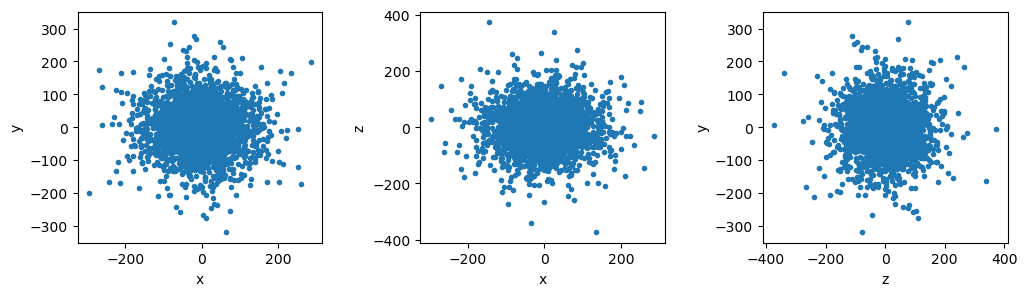

In [104]:
import matplotlib as mpl
import matplotlib.pyplot as plt

ad = ic.all_data()
x = ad["PartType1","particle_position_x"]
y = ad["PartType1","particle_position_y"]
z = ad["PartType1","particle_position_z"]

try:
    sx = ad["PartType4","particle_position_x"]
    sy = ad["PartType4","particle_position_y"]
    sz = ad["PartType4","particle_position_z"]
except:
    sx = None
    sy = None
    sz = None

try:
    bhx = ad["PartType5","particle_position_x"]
    bhy = ad["PartType5","particle_position_y"]
    bhz = ad["PartType5","particle_position_z"]
except:
    bhx = None
    bhy = None
    bhz = None

fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(1,3,1)
ax.plot(x,y,'.')
if sx is not None:
    ax.plot(sx,sy,'.')
if bhx is not None:
    ax.plot(bhx,bhy,'.')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax = fig.add_subplot(1,3,2)
ax.plot(x,z,'.')
if sx is not None:
    ax.plot(sx,sz,'.')
if bhx is not None:
    ax.plot(bhx,bhy,'.')
ax.set_xlabel("x")
ax.set_ylabel("z")
ax = fig.add_subplot(1,3,3)
ax.plot(z,y,'.')
if sx is not None:
    ax.plot(sz,sy,'.')
if bhx is not None:
    ax.plot(bhx,bhy,'.')
ax.set_xlabel("z")
ax.set_ylabel("y")
fig.subplots_adjust(wspace=0.4)

In [67]:
print(ad.quantities.center_of_mass(use_gas=False,use_particles=True))
print(ad.quantities.center_of_mass(use_gas=False,use_particles=True,particle_type="PartType1"))
ad["PartType5","Coordinates"]

[-5.00000000e+00 -6.93463393e-17  1.54102976e-17] code_length
[-5.00000000e+00  0.00000000e+00  2.77555756e-17] code_length


unyt_array([[-5.,  0.,  0.]], 'code_length')

## Load in Snapshot 000 from Gizmo

In [108]:
import yt

ds = yt.load("../../gizmo-public/output/spheric_test_gizmo/snapshot_000.hdf5",bounding_box=[[-300,300]]*3)

plot = yt.ParticleProjectionPlot(ds,"z",("PartType1","Masses"),window_size=(4,4))
try:
    plot.annotate_particles(20,ptype="PartType5",col="orange",p_size=25)
except:
    pass
plot.show()

yt : [INFO     ] 2023-11-15 15:29:15,528 ComovingIntegrationOn != 1 or (not found and OmegaLambda is 0.0), so we are turning off Cosmology.
yt : [INFO     ] 2023-11-15 15:29:15,529 Assuming length units are in kpc (physical)
yt : [INFO     ] 2023-11-15 15:29:15,562 Parameters: current_time              = 0.0
yt : [INFO     ] 2023-11-15 15:29:15,562 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2023-11-15 15:29:15,563 Parameters: domain_left_edge          = [-300. -300. -300.]
yt : [INFO     ] 2023-11-15 15:29:15,564 Parameters: domain_right_edge         = [300. 300. 300.]
yt : [INFO     ] 2023-11-15 15:29:15,564 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2023-11-15 15:29:15,564 A bounding box was explicitly specified, so we are disabling periodicity.
yt : [INFO     ] 2023-11-15 15:29:15,571 Allocating for 1e+04 particles
yt : [INFO     ] 2023-11-15 15:29:15,971 xlim = -300.000000 300.000000
yt : [INFO     ] 2023-11-15 15:29:15,971 ylim = -300.000000 3

YTPlotCallbackError: annotate_particles callback failed

yt : [INFO     ] 2023-11-15 12:21:00,074 ComovingIntegrationOn != 1 or (not found and OmegaLambda is 0.0), so we are turning off Cosmology.
yt : [INFO     ] 2023-11-15 12:21:00,074 Assuming length units are in kpc (physical)
yt : [INFO     ] 2023-11-15 12:21:00,106 Parameters: current_time              = 0.0
yt : [INFO     ] 2023-11-15 12:21:00,106 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2023-11-15 12:21:00,107 Parameters: domain_left_edge          = [-300. -300. -300.]
yt : [INFO     ] 2023-11-15 12:21:00,107 Parameters: domain_right_edge         = [300. 300. 300.]
yt : [INFO     ] 2023-11-15 12:21:00,108 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2023-11-15 12:21:00,108 A bounding box was explicitly specified, so we are disabling periodicity.
yt : [INFO     ] 2023-11-15 12:21:00,114 Allocating for 1e+04 particles
yt : [INFO     ] 2023-11-15 12:21:00,287 xlim = -300.000000 300.000000
yt : [INFO     ] 2023-11-15 12:21:00,287 ylim = -300.000000 3


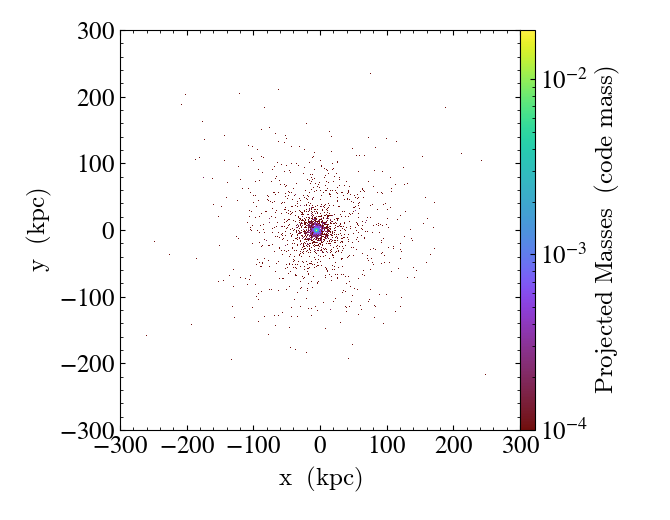

In [70]:
import yt

ds = yt.load("../../gizmo-public/output/spheric_test_gadget/snapshot_000.hdf5",bounding_box=[[-300,300]]*3)

plot = yt.ParticleProjectionPlot(ds,"z",("PartType1","Masses"),window_size=(4,4))
#plot.annotate_particles(20,ptype="PartType5",col="orange",p_size=25)
plot.show()

In [107]:
import yt

ds_giz = yt.load("../../gizmo-public/output/spheric_test_gizmo/snapshot_000.hdf5",bounding_box=[[-300,300]]*3)
ds_gad = yt.load("../../gizmo-public/output/spheric_test_gadget/snapshot_000.hdf5",bounding_box=[[-300,300]]*3)

ad_giz = ds_giz.all_data()
ad_gad = ds_gad.all_data()

print(min(ad_giz["PartType1","ParticleIDs"]))
print(min(ad_gad["PartType1","ParticleIDs"]))

yt : [INFO     ] 2023-11-15 15:29:01,675 ComovingIntegrationOn != 1 or (not found and OmegaLambda is 0.0), so we are turning off Cosmology.
yt : [INFO     ] 2023-11-15 15:29:01,675 Assuming length units are in kpc (physical)
yt : [INFO     ] 2023-11-15 15:29:01,709 Parameters: current_time              = 0.0
yt : [INFO     ] 2023-11-15 15:29:01,710 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2023-11-15 15:29:01,710 Parameters: domain_left_edge          = [-300. -300. -300.]
yt : [INFO     ] 2023-11-15 15:29:01,711 Parameters: domain_right_edge         = [300. 300. 300.]
yt : [INFO     ] 2023-11-15 15:29:01,711 Parameters: cosmological_simulation   = 0
yt : [WARNING  ] 2023-11-15 15:29:01,712 A bounding box was explicitly specified, so we are disabling periodicity.
yt : [INFO     ] 2023-11-15 15:29:01,725 ComovingIntegrationOn != 1 or (not found and OmegaLambda is 0.0), so we are turning off Cosmology.
yt : [INFO     ] 2023-11-15 15:29:01,725 Assuming length units a

1.0 dimensionless
1065353216.0 dimensionless


[7043. 4447.   55.  220.] dimensionless
[1.06698752e+08 1.01382144e+08 4.79723520e+07 6.47495680e+07] dimensionless
giz1=3297 gad1=3297
41.887943267822266 code_length 41.887943267822266 code_length
8.209970341524325 code_velocity 8.209970340749894 code_velocity
Any x-position differences: False
Any velocity differences: True


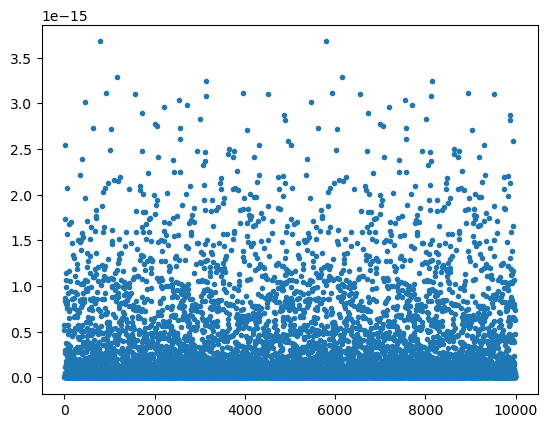

In [109]:
# Note for some reason the gadget particle ids are like logarithmically distributed. I have no idea why
print(ad_giz["PartType1","ParticleIDs"][0:4])
print(ad_gad["PartType1","ParticleIDs"][0:4]-1065353216)
gizpid = ad_giz["PartType1","ParticleIDs"]
gadpid = ad_gad["PartType1","ParticleIDs"]
giz1 = np.argwhere(gizpid==min(gizpid))[0][0]
gad1 = np.argwhere(gadpid==min(gadpid))[0][0]
print(f"{giz1=} {gad1=}")
gizpx = ad_giz['PartType1','particle_position_x']
gadpx = ad_gad['PartType1','particle_position_x']
print(f"{gizpx[giz1]} {gadpx[gad1]}")
gizvx = ad_giz['PartType1','particle_velocity_x']
gadvx = ad_gad['PartType1','particle_velocity_x']
gizc = ad_giz['PartType1','Coordinates']
gadc = ad_gad['PartType1','Coordinates']
gizv = ad_giz['PartType1','Velocities']
gadv = ad_gad['PartType1','Velocities']
print(f"{gizvx[giz1]} {gadvx[gad1]}")

idxgiz = np.argsort(gizpid)
idxgad = np.argsort(gadpid)

def dispvecmag(v1,v2,s=1):
    dv = [v1[i]-s*v2[i] for i,_ in enumerate(v1)]
    dvm = [v*v for v in dv]
    return sum(dvm)

posdiff = np.any(np.abs(gizpx[idxgiz]-gadpx[idxgad])>0)
veldiff = np.any(np.abs(gizvx[idxgiz]-gadvx[idxgad])>0)
print(f"Any x-position differences: {posdiff}")
print(f"Any velocity differences: {veldiff}")

if posdiff:
    plt.plot(gizpx[idxgiz]-gadpx[idxgad],'.')
if veldiff:
    dvm = [dispvecmag(gizv[idxgiz[i]],gadv[idxgad[i]]) for i,_ in enumerate(idxgiz)]
    plt.plot(dvm,'.')
